## Import training dataset

In [3]:
import pandas as pd
import numpy as np

datasets = [
    "solar-wind-imbalance",
    "nuke-temp"
]
future_datasets = [
    'future_wind_solar_imbalance',
    'future_nuke_temp'
]
    
data_names = {
    178: 'Temperature',
    188: 'Nuclear_power',
    245: 'Wind_forecast',
    248: 'Solar_forecast',
    319: 'Price',
}

dataframes = []
future_dataframes = []

print('Import dataset and pivot rows and columns')
for name in datasets:
    data = pd.read_csv(name + ".csv", sep=';', parse_dates=['startTime'])
    data.rename(columns={'startTime': 'DateTime'}, inplace=True)
    data.drop(columns='endTime', inplace=True)
    no_NaN = data.isna().sum()
    print('number of NaN values', no_NaN)
    master_df = data.pivot_table(
        index=data.columns[1], 
        columns=data.columns[0], 
        values=data.columns[2], 
        aggfunc='mean'
    )
    print(master_df.head())
    rows, cols = data.shape
    print('Rows: ', rows)
    dataframes.append(master_df)

Import dataset and pivot rows and columns
number of NaN values datasetId    0
DateTime     0
value        0
dtype: int64
datasetId                     245  248    319
DateTime                                     
2024-02-26 22:00:00+00:00  1147.5  0.0  58.88
2024-02-26 22:15:00+00:00   975.4  0.0    NaN
2024-02-26 22:30:00+00:00   969.6  0.0    NaN
2024-02-26 22:45:00+00:00   960.5  0.0    NaN
2024-02-26 23:00:00+00:00   938.4  0.0  51.00
Rows:  183135
number of NaN values datasetId    0
DateTime     0
value        0
dtype: int64
datasetId                      178     188
DateTime                                  
2024-02-26 22:00:00+00:00  0.76653  4362.0
2024-02-26 22:01:00+00:00  0.76653  4362.0
2024-02-26 22:03:00+00:00  0.76653  4370.5
2024-02-26 22:04:00+00:00  0.76653  4370.5
2024-02-26 22:06:00+00:00  0.76653  4365.4
Rows:  725219


## Import forecast dataset and rename columns

In [4]:
### Future datasets
for name in future_datasets:
    data = pd.read_csv(name + ".csv", sep=';', parse_dates=['startTime'])
    data.rename(columns={'startTime': 'DateTime'}, inplace=True)
    data.drop(columns='endTime', inplace=True)
    no_NaN = data.isna().sum()
    print('number of NaN values', no_NaN)
    data['DateTime'] = pd.to_datetime(data['DateTime'])
    data = data.set_index('DateTime')
    print(data.columns)
    rows, cols = data.shape
    print('Rows: ', rows)
    if data.index.duplicated().any():
        print(f"Warning: Duplicates found in {name}. Grouping by index...")
        data = data.groupby(level=0).mean()
    future_dataframes.append(data)

future_dataframes[0] = future_dataframes[0].rename(columns={
                future_dataframes[0].columns[0]: 'Wind_forecast',
                future_dataframes[0].columns[1]: 'Solar_forecast',
                'Imbalance price': 'Price'
                })
future_dataframes[1] = future_dataframes[1].rename(columns={
                future_dataframes[1].columns[0]: 'Temperature',
                future_dataframes[1].columns[1]: 'Nuclear_power'
                })
print(future_dataframes[0].head())
print('Columns: ', future_dataframes[0].columns)
print(future_dataframes[1].head())
print('Columns: ', future_dataframes[1].columns)


number of NaN values DateTime                                                      0
Wind power generation forecast - updated every 15 minutes     0
Solar power generation forecast - updated every 15 minutes    0
Imbalance price                                               0
dtype: int64
Index(['Wind power generation forecast - updated every 15 minutes',
       'Solar power generation forecast - updated every 15 minutes',
       'Imbalance price'],
      dtype='object')
Rows:  672
number of NaN values DateTime                                      0
Temperature in Helsinki - real time data     32
Nuclear power production - real-time data    36
dtype: int64
Index(['Temperature in Helsinki - real time data', 'Nuclear power production - real-time data'], dtype='object')
Rows:  3374
                           Wind_forecast  Solar_forecast   Price
DateTime                                                        
2026-02-28 22:00:00+00:00          654.2             0.0  154.50
2026-02-28 22:1

### Combine training datasets and check for NaN values

In [5]:
joined_df = pd.concat(dataframes, axis=1).sort_index()
joined_df = joined_df.resample('h').mean()
joined_df = joined_df.rename(columns=data_names)
joined_df.index = joined_df.index.strftime('%Y-%m-%d %H:%M')
print(joined_df.head(n=10))
rows, columns = joined_df.shape
print('Number of NaN in Temperature: ',joined_df['Temperature'].isna().sum())
print('Number of NaN in wind: ',joined_df['Wind_forecast'].isna().sum())
print('Number of NaN in solar: ',joined_df['Solar_forecast'].isna().sum())
print('Number of NaN in nuclear: ',joined_df['Nuclear_power'].isna().sum())
print('Number of NaN in price: ',joined_df['Price'].isna().sum())
print("\ntable size: ", rows, 'rows, ', joined_df.size, 'datapoints')

nan_rows = joined_df[joined_df.isna().any(axis=1)]

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(f"Showing {len(nan_rows)} rows with missing data:\n")
    print(nan_rows)

datasetId         Wind_forecast  Solar_forecast  Price  Temperature  \
DateTime                                                              
2024-02-26 22:00       1013.250           0.000  58.88     0.766530   
2024-02-26 23:00        791.375           0.000  51.00     0.766530   
2024-02-27 00:00        698.375           0.000  50.00     0.766530   
2024-02-27 01:00        754.350           0.000  48.00     0.451566   
2024-02-27 02:00        812.325           0.000  46.00     0.227575   
2024-02-27 03:00        831.000           0.000  46.00     0.185530   
2024-02-27 04:00        851.525           0.125  55.68     0.185530   
2024-02-27 05:00        834.000           0.225  91.37     0.108316   
2024-02-27 06:00        786.500          16.375  96.23    -0.329230   
2024-02-27 07:00        694.200          58.400  51.50     0.101169   

datasetId         Nuclear_power  
DateTime                         
2024-02-26 22:00    4366.424998  
2024-02-26 23:00    4363.784999  
2024-02-27 

### Combine forecast dataset and check for NaN values

In [6]:
future_joined_df = pd.concat(future_dataframes, axis=1).sort_index()
future_joined_df = future_joined_df.resample('h').mean()
future_joined_df.index = future_joined_df.index.strftime('%Y-%m-%d %H:%M')
print(future_joined_df.head(n=10))

rows, columns = future_joined_df.shape
print('Number of NaN values in each column of the future dataset:')
print('Temperature: ',future_joined_df['Temperature'].isna().sum())
print('wind: ',future_joined_df['Wind_forecast'].isna().sum())
print('solar: ',future_joined_df['Solar_forecast'].isna().sum())
print('nuclear: ',future_joined_df['Nuclear_power'].isna().sum())
print('price: ',future_joined_df['Price'].isna().sum())
print("\ntable size: ", rows, 'rows, ', future_joined_df.size, 'datapoints')


                  Wind_forecast  Solar_forecast     Price  Temperature  \
DateTime                                                                 
2026-02-28 22:00        659.225            0.00  117.6250     1.003020   
2026-02-28 23:00        595.675            0.00  229.1250     0.899050   
2026-03-01 00:00        652.975            0.00   60.6625     0.899050   
2026-03-01 01:00        666.950            0.00  292.2500     0.899050   
2026-03-01 02:00        600.350            0.00  176.0000     0.421755   
2026-03-01 03:00        611.250            0.00   86.2500     0.486220   
2026-03-01 04:00        663.125            0.00   48.7500     0.486220   
2026-03-01 05:00       1027.025            0.00   13.8325     0.486220   
2026-03-01 06:00       1458.550           24.55    7.8925     0.486220   
2026-03-01 07:00       1731.825           56.80   18.9850     0.722095   

                  Nuclear_power  
DateTime                         
2026-02-28 22:00       4234.520  
2026-02-2

### Interpolate the missing values on rows that include less than 3 conscutive lines, Training dataset

In [7]:
interpol_df = joined_df.interpolate(method='linear', limit=2)
print(interpol_df.head())
nanvals = interpol_df.isna().sum()
print(nanvals)

nan_rows = interpol_df[interpol_df.isna().any(axis=1)]

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(f"Showing {len(nan_rows)} rows with missing data:\n")
    print(nan_rows)

datasetId         Wind_forecast  Solar_forecast  Price  Temperature  \
DateTime                                                              
2024-02-26 22:00       1013.250             0.0  58.88     0.766530   
2024-02-26 23:00        791.375             0.0  51.00     0.766530   
2024-02-27 00:00        698.375             0.0  50.00     0.766530   
2024-02-27 01:00        754.350             0.0  48.00     0.451566   
2024-02-27 02:00        812.325             0.0  46.00     0.227575   

datasetId         Nuclear_power  
DateTime                         
2024-02-26 22:00    4366.424998  
2024-02-26 23:00    4363.784999  
2024-02-27 00:00    4364.199997  
2024-02-27 01:00    4364.689999  
2024-02-27 02:00    4363.679998  
datasetId
Wind_forecast      0
Solar_forecast     0
Price              0
Temperature       29
Nuclear_power     29
dtype: int64
Showing 29 rows with missing data:

datasetId         Wind_forecast  Solar_forecast      Price  Temperature  \
DateTime                 

In [8]:
cleaned_df = interpol_df.dropna()
print(cleaned_df.head())
nanvals = cleaned_df.isna().sum()
print(nanvals)
cleaned_df.head()

datasetId         Wind_forecast  Solar_forecast  Price  Temperature  \
DateTime                                                              
2024-02-26 22:00       1013.250             0.0  58.88     0.766530   
2024-02-26 23:00        791.375             0.0  51.00     0.766530   
2024-02-27 00:00        698.375             0.0  50.00     0.766530   
2024-02-27 01:00        754.350             0.0  48.00     0.451566   
2024-02-27 02:00        812.325             0.0  46.00     0.227575   

datasetId         Nuclear_power  
DateTime                         
2024-02-26 22:00    4366.424998  
2024-02-26 23:00    4363.784999  
2024-02-27 00:00    4364.199997  
2024-02-27 01:00    4364.689999  
2024-02-27 02:00    4363.679998  
datasetId
Wind_forecast     0
Solar_forecast    0
Price             0
Temperature       0
Nuclear_power     0
dtype: int64


datasetId,Wind_forecast,Solar_forecast,Price,Temperature,Nuclear_power
DateTime,,,,,
2024-02-26 22:00,1013.250,0.0,58.88,0.766530,4366.424998
2024-02-26 23:00,791.375,0.0,51.00,0.766530,4363.784999
2024-02-27 00:00,698.375,0.0,50.00,0.766530,4364.199997
2024-02-27 01:00,754.350,0.0,48.00,0.451566,4364.689999
2024-02-27 02:00,812.325,0.0,46.00,0.227575,4363.679998


### Separate the timedate into separate columns for the model

In [9]:
#Training dataset
cleaned_df.index = pd.to_datetime(cleaned_df.index)

cleaned_df.loc[:, 'Day_of_week'] = cleaned_df.index.dayofweek
cleaned_df.loc[:, 'Hour'] = cleaned_df.index.hour.to_numpy()
cleaned_df.loc[:, 'Month'] = cleaned_df.index.month.to_numpy()
cleaned_df.loc[:, 'Year'] = cleaned_df.index.year.to_numpy()

cleaned_df

/tmp/ipykernel_281/1698027070.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_df.loc[:, 'Day_of_week'] = cleaned_df.index.dayofweek
/tmp/ipykernel_281/1698027070.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_df.loc[:, 'Hour'] = cleaned_df.index.hour.to_numpy()
/tmp/ipykernel_281/1698027070.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: ht

datasetId,Wind_forecast,Solar_forecast,Price,Temperature,Nuclear_power,Day_of_week,Hour,Month,Year
DateTime,,,,,,,,,
2024-02-26 22:00:00,1013.250,0.0,58.8800,0.766530,4366.424998,0,22,2,2024
2024-02-26 23:00:00,791.375,0.0,51.0000,0.766530,4363.784999,0,23,2,2024
2024-02-27 00:00:00,698.375,0.0,50.0000,0.766530,4364.199997,1,0,2,2024
2024-02-27 01:00:00,754.350,0.0,48.0000,0.451566,4364.689999,1,1,2,2024
2024-02-27 02:00:00,812.325,0.0,46.0000,0.227575,4363.679998,1,2,2,2024
...,...,...,...,...,...,...,...,...,...
2026-02-27 17:00:00,1609.750,0.0,102.9350,2.098595,4234.535000,4,17,2,2026
2026-02-27 18:00:00,1428.000,0.0,68.9750,1.714500,4234.155000,4,18,2,2026
2026-02-27 19:00:00,1165.675,0.0,96.4650,1.714500,4233.975000,4,19,2,2026


In [10]:
#Forecasting dataset
future_df = future_joined_df.copy()
future_df.index = pd.to_datetime(future_df.index)
future_df.loc[:, 'Day_of_week'] = future_df.index.dayofweek
future_df.loc[:, 'Hour'] = future_df.index.hour.to_numpy()
future_df.loc[:, 'Month'] = future_df.index.month.to_numpy()
future_df.loc[:, 'Year'] = future_df.index.year.to_numpy()

future_df

,Wind_forecast,Solar_forecast,Price,Temperature,Nuclear_power,Day_of_week,Hour,Month,Year
DateTime,,,,,,,,,
2026-02-28 22:00:00,659.225,0.0,117.6250,1.003020,4234.5200,5,22,2,2026
2026-02-28 23:00:00,595.675,0.0,229.1250,0.899050,4234.4900,5,23,2,2026
2026-03-01 00:00:00,652.975,0.0,60.6625,0.899050,4234.3350,6,0,3,2026
2026-03-01 01:00:00,666.950,0.0,292.2500,0.899050,4233.0700,6,1,3,2026
2026-03-01 02:00:00,600.350,0.0,176.0000,0.421755,4233.3450,6,2,3,2026
...,...,...,...,...,...,...,...,...,...
2026-03-07 17:00:00,4861.300,0.0,16.0525,-0.148700,4230.7170,5,17,3,2026
2026-03-07 18:00:00,5440.825,0.0,0.9125,-1.454100,4231.1555,5,18,3,2026
2026-03-07 19:00:00,5744.475,0.0,-0.5000,-2.250600,4231.3635,5,19,3,2026


### Visualize the training dataset

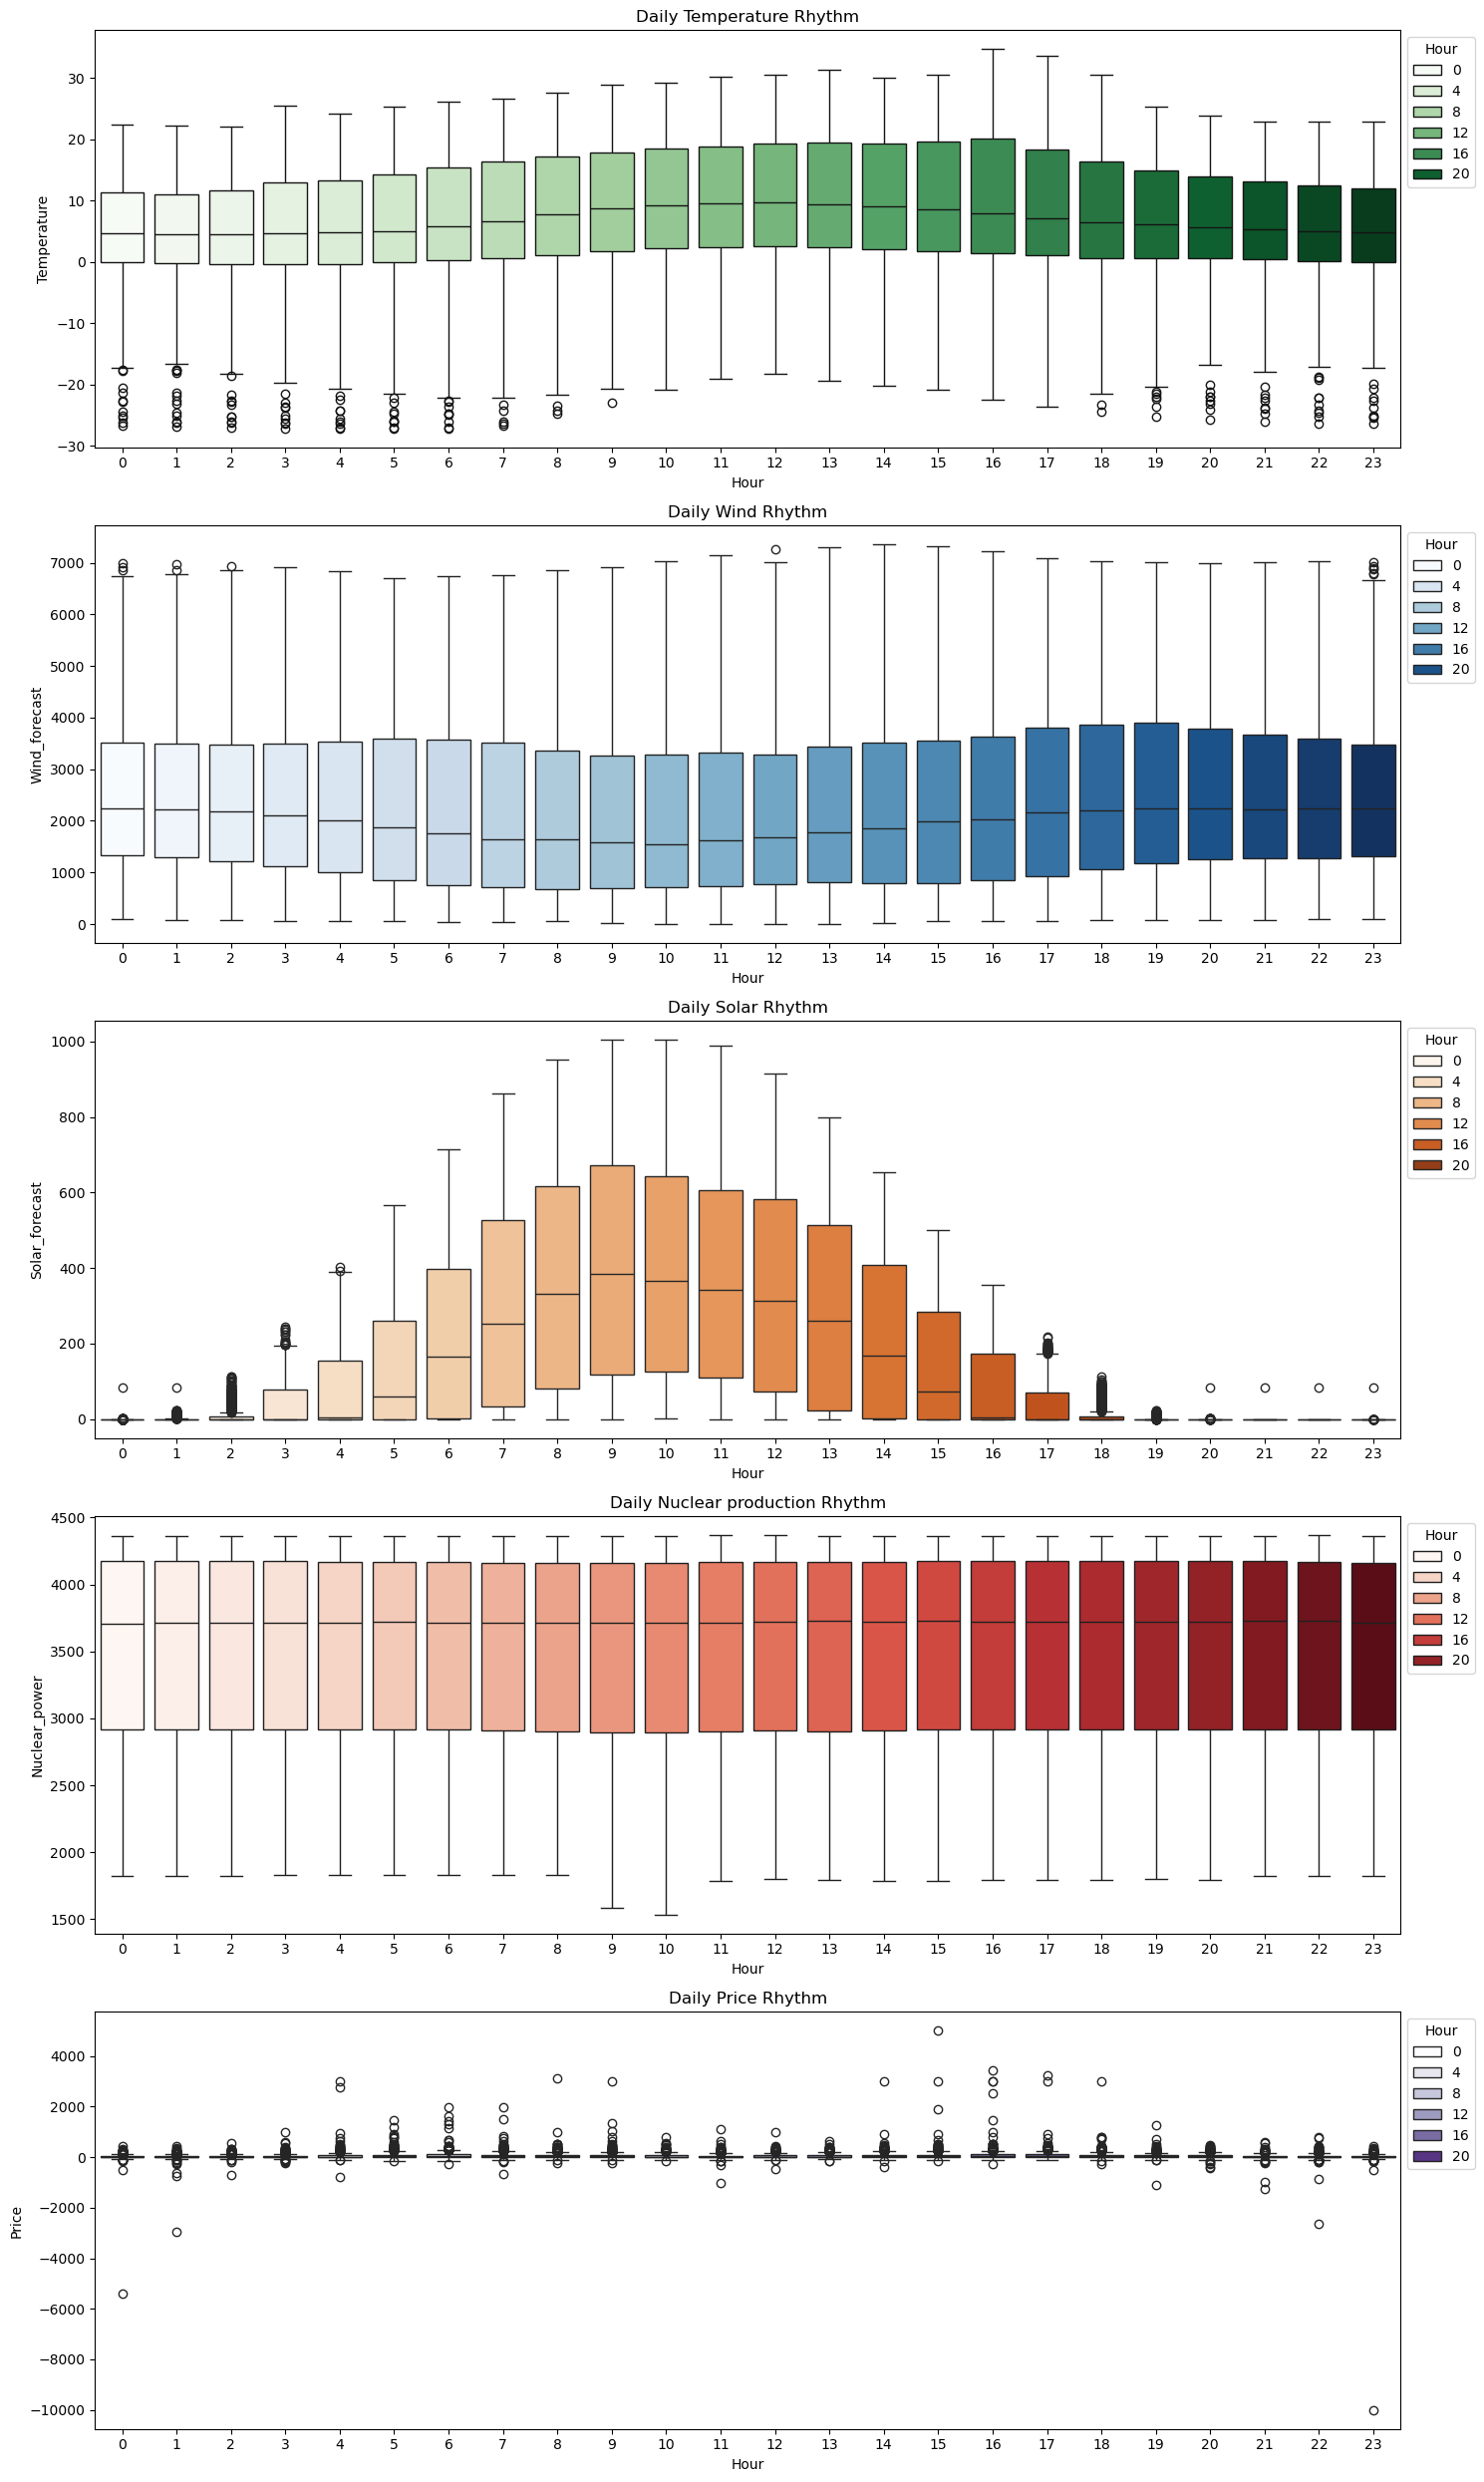

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

df_for_box = cleaned_df.copy()
df_for_box.index = pd.to_datetime(df_for_box.index)
df_for_box['Hour'] = df_for_box.index.hour

cols = ['Temperature', 'Wind_forecast', 'Solar_forecast', 'Nuclear_power', 'Price']
palettes = ["Greens", "Blues", "Oranges", "Reds", "Purples"]
titles = ['Daily Temperature Rhythm', 'Daily Wind Rhythm', 'Daily Solar Rhythm', 'Daily Nuclear production Rhythm', 'Daily Price Rhythm']

fig, axs = plt.subplots(5, 1, figsize=(15, 25))

for i in range(len(cols)):
    sns.boxplot(data=df_for_box, x='Hour', y=cols[i], ax=axs[i], palette=palettes[i], hue='Hour')
    axs[i].set_title(titles[i])
    axs[i].legend(bbox_to_anchor=(1, 1), loc='upper left', title='Hour')

plt.tight_layout()
plt.show()

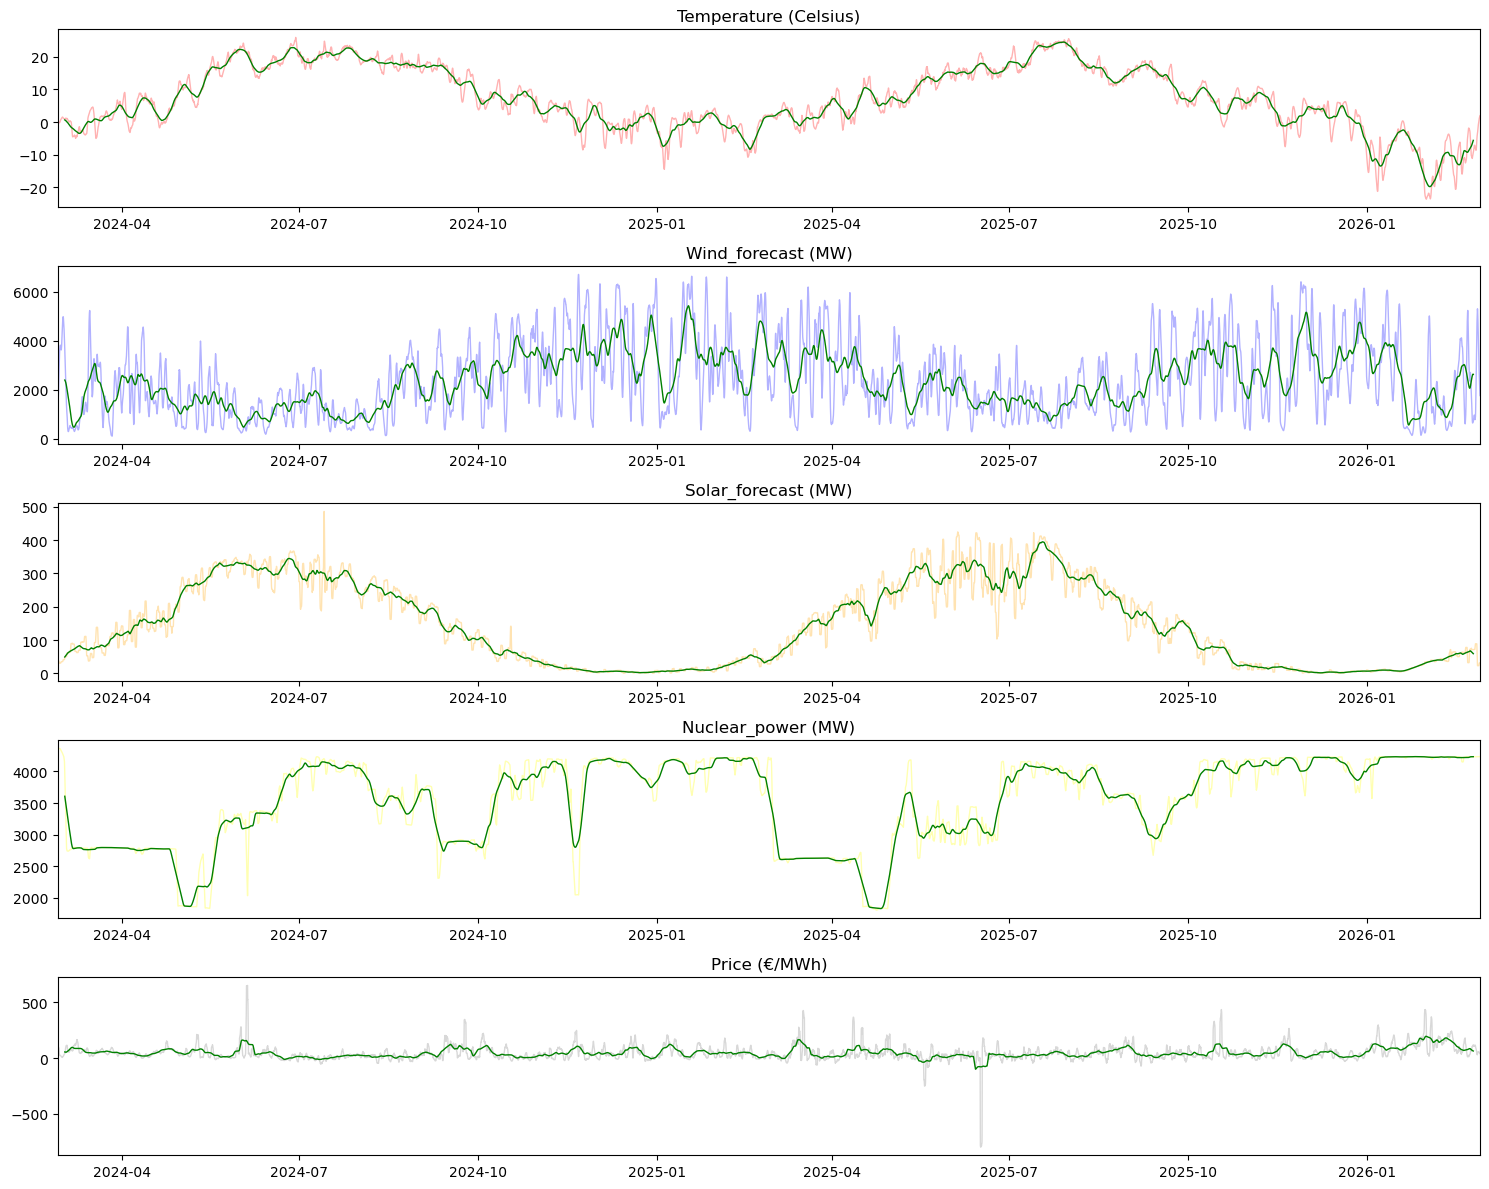

In [12]:
colors = ['red', 'blue', 'orange', 'yellow', 'grey']
smoothed_datas = []

for col in cols:
    smoothed_datas.append(cleaned_df[col].rolling(window=24).mean())

fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(15, 12)) 
    
for index in range(5):
    moving_avg = smoothed_datas[index].rolling(window=168, center=True).mean()
    title_end = ' (Celsius)' if index == 0 else ' (MW)' if index < 4 else ' (€/MWh)'
    axes[index].plot(cleaned_df.index, smoothed_datas[index], alpha=0.3, color=colors[index], lw=1)
    axes[index].plot(cleaned_df.index, moving_avg, color='green', linewidth=1, label='7-Day Moving Avg')
    axes[index].set_title(cols[index] + title_end)
    axes[index].margins(x=0)

plt.tight_layout()
plt.show()

### Create labelling for the classification based on 7 day rolling median

In [13]:
model_df = cleaned_df.copy()

model_df['Rolling median'] = cleaned_df['Price'].rolling(window=168, closed='left').median()

threshold = 0.3 
min_difference = 20

# Labelling the target values
def assign_label(row):
    if pd.isna(row['Rolling median']):
        return np.nan
    offset = max(row['Rolling median'] * threshold, min_difference)

    upper_threshold = row['Rolling median'] + offset
    lower_threshold = row['Rolling median'] - offset
    if row['Price'] > upper_threshold:
        return 2  
    elif row['Price'] < lower_threshold:
        return 0 
    else:
        return 1  

model_df.loc[:, 'Target'] = model_df.apply(assign_label, axis=1)

model_df = model_df.dropna()
model_df

datasetId,Wind_forecast,Solar_forecast,Price,Temperature,Nuclear_power,Day_of_week,Hour,Month,Year,Rolling median,Target
DateTime,,,,,,,,,,,
2024-03-04 22:00:00,506.650,0.0,49.0000,0.730860,2765.519999,0,22,3,2024,36.13500,1.0
2024-03-04 23:00:00,479.850,0.0,49.2100,0.928860,2767.344997,0,23,3,2024,36.13500,1.0
2024-03-05 00:00:00,431.275,0.0,49.4800,1.093495,2767.239997,1,0,3,2024,36.13500,1.0
2024-03-05 01:00:00,441.600,0.0,49.4600,0.110214,2767.534999,1,1,3,2024,36.13500,1.0
2024-03-05 02:00:00,454.500,0.0,104.0000,-0.875982,2767.199998,1,2,3,2024,36.13500,2.0
...,...,...,...,...,...,...,...,...,...,...,...
2026-02-27 17:00:00,1609.750,0.0,102.9350,2.098595,4234.535000,4,17,2,2026,56.70750,2.0
2026-02-27 18:00:00,1428.000,0.0,68.9750,1.714500,4234.155000,4,18,2,2026,58.74625,1.0
2026-02-27 19:00:00,1165.675,0.0,96.4650,1.714500,4233.975000,4,19,2,2026,60.29000,2.0


In [14]:
print(model_df['Target'].value_counts(normalize=True))

Target
1.0    0.354556
2.0    0.350354
0.0    0.295090
Name: proportion, dtype: float64


### Create 1h and 24h lag columns for the time series

In [15]:
# Adding lags to each variable, since it is time series data, Training dataset
features_to_lag_1h = ['Price', 'Wind_forecast', 'Nuclear_power', 'Solar_forecast' ]
features_to_lag_24h = ['Price', 'Temperature']

for col in features_to_lag_1h:
    # 1-hour lag
    model_df.loc[:, f'{col}_diff_1h'] = model_df.loc[:, col].diff(1)
    
    if col in features_to_lag_24h:
        model_df.loc[:, f'{col}_diff_24h'] = model_df.loc[:, col].diff(24)
     
    
model_df.loc[:, 'Temperature_lag24'] = model_df.loc[:, 'Temperature'].diff(24)

model_df = model_df.dropna()
model_df

datasetId,Wind_forecast,Solar_forecast,Price,Temperature,Nuclear_power,Day_of_week,Hour,Month,Year,Rolling median,Target,Price_diff_1h,Price_diff_24h,Wind_forecast_diff_1h,Nuclear_power_diff_1h,Solar_forecast_diff_1h,Temperature_lag24
DateTime,,,,,,,,,,,,,,,,,
2024-03-05 22:00:00,501.000,0.0,56.5800,-6.481720,2798.199996,1,22,3,2024,43.27500,1.0,-44.9200,7.5800,-56.225,-0.095001,0.0,-7.212580
2024-03-05 23:00:00,464.600,0.0,59.0000,-6.971636,2798.229996,1,23,3,2024,44.36000,1.0,2.4200,9.7900,-36.400,0.030000,0.0,-7.900496
2024-03-06 00:00:00,454.275,0.0,59.0000,-7.551122,2798.349998,2,0,3,2024,44.36000,1.0,0.0000,9.5200,-10.325,0.120002,0.0,-8.644617
2024-03-06 01:00:00,506.925,0.0,59.0000,-8.106180,2799.169996,2,1,3,2024,45.00000,1.0,0.0000,9.5400,52.650,0.819998,0.0,-8.216394
2024-03-06 02:00:00,583.100,0.0,59.0000,-8.665833,2798.584996,2,2,3,2024,45.00000,1.0,0.0000,-45.0000,76.175,-0.585000,0.0,-7.789851
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-27 17:00:00,1609.750,0.0,102.9350,2.098595,4234.535000,4,17,2,2026,56.70750,2.0,33.1775,5.0350,-108.425,0.460000,0.0,2.378407
2026-02-27 18:00:00,1428.000,0.0,68.9750,1.714500,4234.155000,4,18,2,2026,58.74625,1.0,-33.9600,-34.6250,-181.750,-0.380000,0.0,1.681880
2026-02-27 19:00:00,1165.675,0.0,96.4650,1.714500,4233.975000,4,19,2,2026,60.29000,2.0,27.4900,36.6725,-262.325,-0.180000,0.0,1.580903


In [16]:
#Lags for the forecasting dataset
february_buffer_for_lags = cleaned_df.iloc[-24:].copy()

# 3. Stitch them together
forecast_data = pd.concat([february_buffer_for_lags, future_df])

# 4. NOW generate the signals for the whole block
for col in features_to_lag_1h:
    forecast_data[f'{col}_diff_1h'] = forecast_data[col].diff(1)
    if col in features_to_lag_24h:
        forecast_data[f'{col}_diff_24h'] = forecast_data[col].diff(24)
    
forecast_data.loc[:, 'Temperature_lag24'] = forecast_data.loc[:, 'Temperature'].diff(24)
"""
# 5. Add the time features (Hour, Day, Month)
forecast_data['Hour'] = forecast_data.index.hour
forecast_data['Day_of_week'] = forecast_data.index.dayofweek
forecast_data['Month'] = forecast_data.index.month
"""
# X for forecasting
forecast_data = forecast_data.iloc[24:].copy()
X_forecast = forecast_data.drop(columns=['Price'])
forecast_data

,Wind_forecast,Solar_forecast,Price,Temperature,Nuclear_power,Day_of_week,Hour,Month,Year,Price_diff_1h,Price_diff_24h,Wind_forecast_diff_1h,Nuclear_power_diff_1h,Solar_forecast_diff_1h,Temperature_lag24
DateTime,,,,,,,,,,,,,,,
2026-02-28 22:00:00,659.225,0.0,117.6250,1.003020,4234.5200,5,22,2,2026,68.3375,94.7650,-399.800,0.2500,0.0,0.618730
2026-02-28 23:00:00,595.675,0.0,229.1250,0.899050,4234.4900,5,23,2,2026,111.5000,207.4550,-63.550,-0.0300,0.0,0.101585
2026-03-01 00:00:00,652.975,0.0,60.6625,0.899050,4234.3350,6,0,3,2026,-168.4625,43.4175,57.300,-0.1550,0.0,-0.318558
2026-03-01 01:00:00,666.950,0.0,292.2500,0.899050,4233.0700,6,1,3,2026,231.5875,279.7525,13.975,-1.2650,0.0,-0.570850
2026-03-01 02:00:00,600.350,0.0,176.0000,0.421755,4233.3450,6,2,3,2026,-116.2500,172.2025,-66.600,0.2750,0.0,-1.150086
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-07 17:00:00,4861.300,0.0,16.0525,-0.148700,4230.7170,5,17,3,2026,7.0625,-37.4050,494.700,-2.3190,0.0,-0.309200
2026-03-07 18:00:00,5440.825,0.0,0.9125,-1.454100,4231.1555,5,18,3,2026,-15.1400,-28.3775,579.525,0.4385,0.0,-0.943250
2026-03-07 19:00:00,5744.475,0.0,-0.5000,-2.250600,4231.3635,5,19,3,2026,-1.4125,-0.5000,303.650,0.2080,0.0,-0.861250


### Visualize the training dataset is clean for training

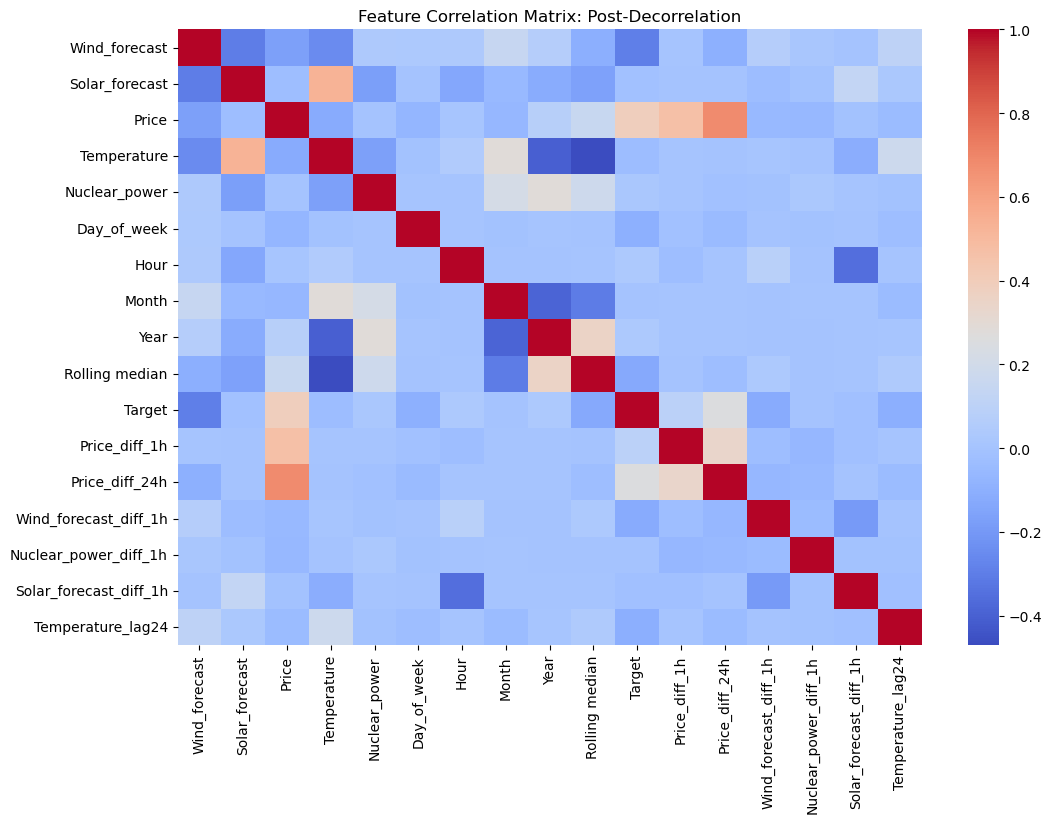

In [17]:
#Heatmap to verify the dataset is clean enough for training, in this case meaning the data is decorrelated to avoid possible overfitting.
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(model_df.corr(), annot=False, cmap='coolwarm')
plt.title('Feature Correlation Matrix: Post-Decorrelation')
plt.xlabel('')
plt.ylabel('')
plt.show()

In [18]:
#X and y for training
X_train = model_df.drop(columns=['Target', 'Price', 'Rolling median'])
y_train = model_df['Target']

#Check column match
print(X_forecast.columns)
print(X_train.columns)
X_train

Index(['Wind_forecast', 'Solar_forecast', 'Temperature', 'Nuclear_power',
       'Day_of_week', 'Hour', 'Month', 'Year', 'Price_diff_1h',
       'Price_diff_24h', 'Wind_forecast_diff_1h', 'Nuclear_power_diff_1h',
       'Solar_forecast_diff_1h', 'Temperature_lag24'],
      dtype='object')
Index(['Wind_forecast', 'Solar_forecast', 'Temperature', 'Nuclear_power',
       'Day_of_week', 'Hour', 'Month', 'Year', 'Price_diff_1h',
       'Price_diff_24h', 'Wind_forecast_diff_1h', 'Nuclear_power_diff_1h',
       'Solar_forecast_diff_1h', 'Temperature_lag24'],
      dtype='object', name='datasetId')


datasetId,Wind_forecast,Solar_forecast,Temperature,Nuclear_power,Day_of_week,Hour,Month,Year,Price_diff_1h,Price_diff_24h,Wind_forecast_diff_1h,Nuclear_power_diff_1h,Solar_forecast_diff_1h,Temperature_lag24
DateTime,,,,,,,,,,,,,,
2024-03-05 22:00:00,501.000,0.0,-6.481720,2798.199996,1,22,3,2024,-44.9200,7.5800,-56.225,-0.095001,0.0,-7.212580
2024-03-05 23:00:00,464.600,0.0,-6.971636,2798.229996,1,23,3,2024,2.4200,9.7900,-36.400,0.030000,0.0,-7.900496
2024-03-06 00:00:00,454.275,0.0,-7.551122,2798.349998,2,0,3,2024,0.0000,9.5200,-10.325,0.120002,0.0,-8.644617
2024-03-06 01:00:00,506.925,0.0,-8.106180,2799.169996,2,1,3,2024,0.0000,9.5400,52.650,0.819998,0.0,-8.216394
2024-03-06 02:00:00,583.100,0.0,-8.665833,2798.584996,2,2,3,2024,0.0000,-45.0000,76.175,-0.585000,0.0,-7.789851
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-27 17:00:00,1609.750,0.0,2.098595,4234.535000,4,17,2,2026,33.1775,5.0350,-108.425,0.460000,0.0,2.378407
2026-02-27 18:00:00,1428.000,0.0,1.714500,4234.155000,4,18,2,2026,-33.9600,-34.6250,-181.750,-0.380000,0.0,1.681880
2026-02-27 19:00:00,1165.675,0.0,1.714500,4233.975000,4,19,2,2026,27.4900,36.6725,-262.325,-0.180000,0.0,1.580903


In [19]:

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

tscv = TimeSeriesSplit(n_splits=5)

pipelines = {
    'LR': Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression())]),
    'XGB': Pipeline([('clf', XGBClassifier())]),
    'MLP': Pipeline([('scaler', StandardScaler()), ('clf', MLPClassifier(max_iter=2000))]),
    'SVC': Pipeline([('scaler', StandardScaler()), ('clf', SVC(gamma='auto'))])
}

param_grids = {
    'LR': {'clf__C': [0.1, 1, 10], 'clf__penalty': ['l2']},
    'XGB': {'clf__n_estimators': [100, 200], 'clf__max_depth': [3, 6], 'clf__learning_rate': [0.01, 0.1]},
    'MLP': {'clf__hidden_layer_sizes': [(50,), (100, 50)], 'clf__alpha': [0.0001, 0.001]},
    'SVC': {'clf__C': [0.1, 1.0, 5.0], 'clf__kernel': ['linear', 'poly', 'sigmoid']}
}

scoring_metrics = {
    'accuracy': 'accuracy',
    'f1_macro': 'f1_macro',           # Use 'f1_macro' instead of 'f1'
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro'
}

results_list = []
best_models = {}
for name in pipelines:
    print(f"Training {name}...")
    grid = GridSearchCV(pipelines[name], param_grids[name], cv=tscv, scoring=scoring_metrics, refit='f1_macro', n_jobs=-1)
    grid.fit(X_train, y_train)
    best_models[name] = grid.best_estimator_
    print(f"Best Score for {name}: {grid.best_score_}")
    idx = grid.best_index_
    results_list.append({
        'Model': name,
        'F1-Score (Macro)': grid.cv_results_['mean_test_f1_macro'][idx],
        'Accuracy': grid.cv_results_['mean_test_accuracy'][idx],
        'Precision': grid.cv_results_['mean_test_precision_macro'][idx],
        'Fit Time (s)': grid.cv_results_['mean_fit_time'][idx]
    })
print('Model training complete!')

Training LR...
Best Score for LR: 0.46076162040425944
Training XGB...
Best Score for XGB: 0.6159317193958282
Training MLP...


/opt/software/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Best Score for MLP: 0.49785200816267566
Training SVC...
Best Score for SVC: 0.48655308485788523
Model training complete!


In [20]:
comparison_df = pd.DataFrame(results_list).sort_values(by='F1-Score (Macro)', ascending=False)
comparison_df.loc[:, 'Model'] = ['XGBoost Classifier', 'Multi-Layer-Percetron Classifier', 'Support Vector Classifier', 'Logistic Regression']
display(comparison_df)

,Model,F1-Score (Macro),Accuracy,Precision,Fit Time (s)
1,XGBoost Classifier,0.615932,0.624213,0.625437,0.819718
2,Multi-Layer-Percetron Classifier,0.504617,0.536423,0.555186,16.265641
3,Support Vector Classifier,0.486553,0.516154,0.522136,6.521540
0,Logistic Regression,0.460762,0.502525,0.498132,0.087969


In [21]:
print(best_models['XGB'])

Pipeline(steps=[('clf',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric=None,
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,


In [30]:
prediction = best_models['XGB'].predict(X_forecast)
forecast_data['prediction'] = prediction - 1
forecast_data.head()

,Wind_forecast,Solar_forecast,Price,Temperature,Nuclear_power,Day_of_week,Hour,Month,Year,Price_diff_1h,Price_diff_24h,Wind_forecast_diff_1h,Nuclear_power_diff_1h,Solar_forecast_diff_1h,Temperature_lag24,prediction
DateTime,,,,,,,,,,,,,,,,
2026-02-28 22:00:00,659.225,0.0,117.6250,1.003020,4234.520,5,22,2,2026,68.3375,94.7650,-399.800,0.250,0.0,0.618730,1
2026-02-28 23:00:00,595.675,0.0,229.1250,0.899050,4234.490,5,23,2,2026,111.5000,207.4550,-63.550,-0.030,0.0,0.101585,1
2026-03-01 00:00:00,652.975,0.0,60.6625,0.899050,4234.335,6,0,3,2026,-168.4625,43.4175,57.300,-0.155,0.0,-0.318558,0
2026-03-01 01:00:00,666.950,0.0,292.2500,0.899050,4233.070,6,1,3,2026,231.5875,279.7525,13.975,-1.265,0.0,-0.570850,1
2026-03-01 02:00:00,600.350,0.0,176.0000,0.421755,4233.345,6,2,3,2026,-116.2500,172.2025,-66.600,0.275,0.0,-1.150086,1


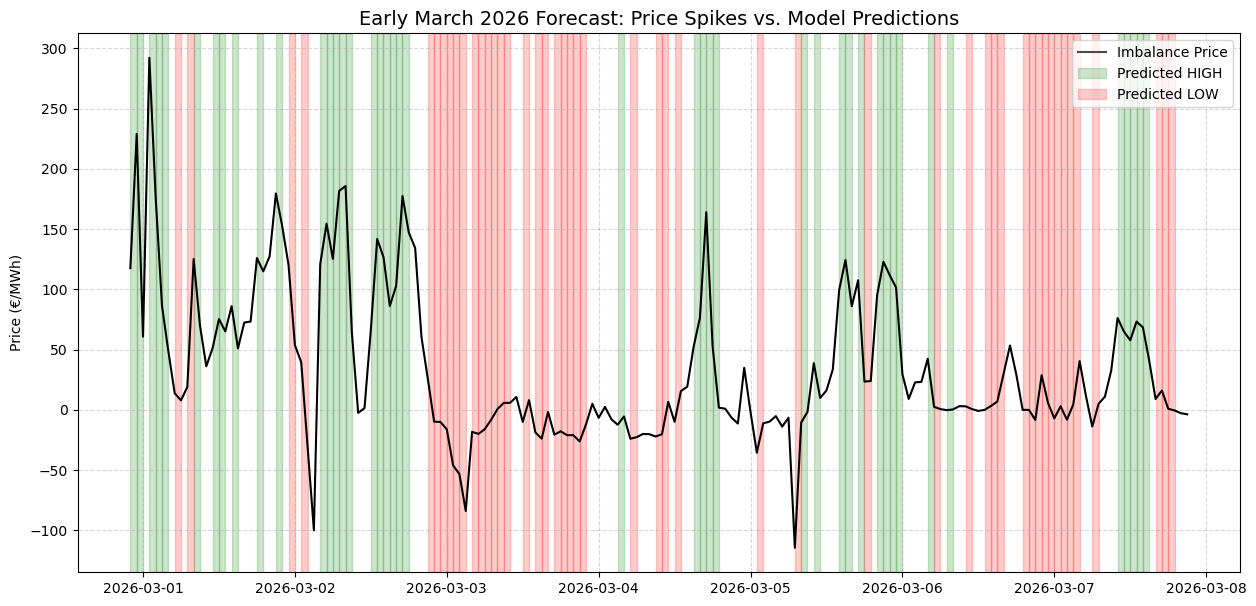

In [41]:
import matplotlib.patches as mpatches

plt.figure(figsize=(15, 7))
plt.plot(forecast_data.index, forecast_data['Price'], color='black', alpha=0.7)

for i in range(len(forecast_data)):
    if forecast_data['prediction'].iloc[i] == 1: # Short (Price high)
        plt.axvspan(forecast_data.index[i], forecast_data.index[i] + pd.Timedelta(hours=1), color='green', alpha=0.2)
    elif forecast_data['prediction'].iloc[i] == -1: # Long (Price low)
        plt.axvspan(forecast_data.index[i], forecast_data.index[i] + pd.Timedelta(hours=1), color='red', alpha=0.2)
       
legend_color_high = mpatches.Patch(color='green', alpha=0.2, label='Predicted HIGH')
legend_color_low= mpatches.Patch(color='red', alpha=0.2, label='Predicted LOW')
price_line = plt.Line2D([0], [0], color='black', alpha=0.7, label='Imbalance Price')
        
plt.title('Early March 2026 Forecast: Price Spikes vs. Model Predictions', fontsize=14)
plt.ylabel('Price (€/MWh)')
plt.legend(handles=[price_line, legend_color_high, legend_color_low], frameon=True)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()